In [22]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage.io as skio
import matplotlib.patches as mpatches

import os
import json
import scipy.stats as stats
from collections import defaultdict
import tqdm

import sklearn.preprocessing
import sklearn.model_selection
import sklearn.pipeline 
import sklearn.linear_model

import warnings
warnings.filterwarnings(action='ignore')#,category=sklearn.exceptions.ConvergenceWarning)

In [23]:
DATA_DIR = os.path.expanduser("data/fingernail-anemia")
CSV_PATH = os.path.join(DATA_DIR, "metadata.csv")
metadata = pd.read_csv(CSV_PATH)

In [24]:
metadata.head()

,PATIENT_ID,MEASUREMENT_DATE,HB_LEVEL_GperL,NAIL_BOUNDING_BOXES,SKIN_BOUNDING_BOXES
0,1,14b0293a34344cc4fba0fa39d5370c52,134.0,"[[251, 447, 302, 505], [123, 429, 183, 483], [...","[[267, 586, 324, 627], [148, 556, 200, 614], [..."
1,2,14b0293a34344cc4fba0fa39d5370c52,108.0,"[[236, 503, 281, 556], [148, 457, 195, 514], [...","[[252, 612, 294, 647], [162, 585, 212, 632], [..."
2,5,14b0293a34344cc4fba0fa39d5370c52,84.0,"[[244, 508, 277, 562], [183, 448, 220, 505], [...","[[264, 629, 303, 662], [193, 584, 232, 619], [..."
3,6,14b0293a34344cc4fba0fa39d5370c52,138.0,"[[311, 456, 363, 521], [182, 408, 237, 471], [...","[[318, 609, 380, 650], [189, 562, 245, 616], [..."
4,7,14b0293a34344cc4fba0fa39d5370c52,119.0,"[[29, 513, 78, 556], [119, 435, 165, 479], [18...","[[29, 635, 79, 678], [117, 564, 175, 615], [20..."


In [25]:
metadata['NAIL_BOUNDING_BOXES'] = metadata['NAIL_BOUNDING_BOXES'].apply(json.loads)
metadata['SKIN_BOUNDING_BOXES'] = metadata['SKIN_BOUNDING_BOXES'].apply(json.loads)

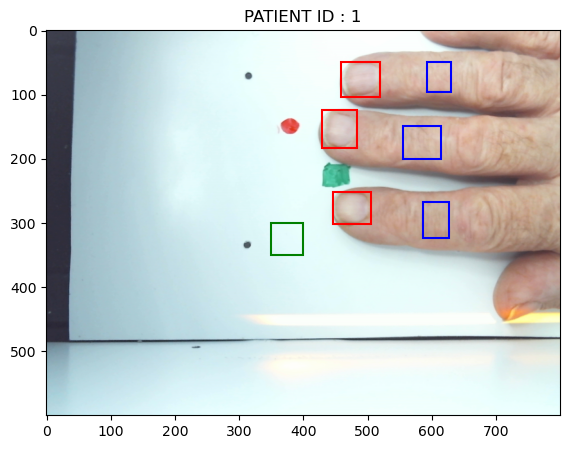

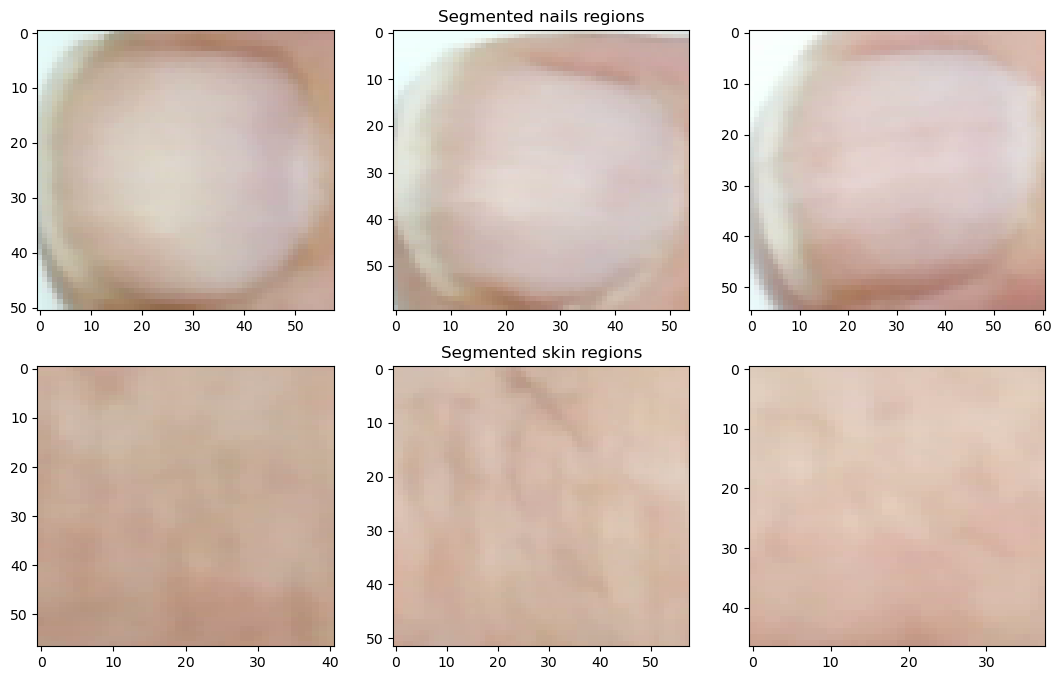

In [26]:
image_folder = 'data/photo/'
N_MAX_IMAGES = 1

for j,(_, row) in enumerate(metadata.iterrows()):
    
    if j ==  N_MAX_IMAGES:
        break
    
    label = 'Anemic' if row.HB_LEVEL_GperL < 120 else 'Non-anemic'
    img_path = os.path.join(DATA_DIR ,label, f'{row.PATIENT_ID}.jpg')
    
    img = skio.imread(img_path)
    
    plt.figure(figsize=(7,5))
    plt.imshow(img)
    
    nails_bboxes = row.NAIL_BOUNDING_BOXES
    skin_bboxes  = row.SKIN_BOUNDING_BOXES
    
    ax = plt.gca()
    
    for _color,_bboxes in zip(['r','b'],[nails_bboxes,skin_bboxes]):
        for top,left,bot,right in _bboxes:
            
            w,h = right-left,bot-top
            
            rectangle = mpatches.Rectangle(xy=(left,top),width=w,height=h,fill=None,
                                           color=_color,linewidth=1.5)
            
            ax.add_patch(rectangle)
            
    white_region_rectangle = mpatches.Rectangle(xy=(350,300),width=50,height=50,fill=None,
                                           color='green',linewidth=1.5)
    ax.add_patch(white_region_rectangle)
    
    plt.title(f"PATIENT ID : {row.PATIENT_ID}")
    
    fig,axs = plt.subplots(2,3,figsize=(13,8))
    axs = axs.ravel()
    
    all_bboxes = nails_bboxes + skin_bboxes
    
    for i,(top,left,bot,right) in enumerate(all_bboxes):
        axs[i].imshow(img[top:bot,left:right],aspect='auto')
        if i == 1:
            axs[i].set_title("Segmented nails regions")
        if i == 4:
            axs[i].set_title("Segmented skin regions")
        
    plt.show()

In [27]:
def cut_image(img,low=0.2,high=0.8):
    h,w = img.shape[:2]
    return img[int(low*h):int(high*h),int(low*w):int(high*w),:]

def calculate_features(img,percentile_levels=[5,15,25,50,75,85,95],low=0.2,high=0.8):
    features_dict = {}
    for color_chan_id,color in enumerate('RGB'):
        for percentile_level in percentile_levels:
            
            cutted_image = cut_image(img,low=low,high=high)
            feature_value = np.percentile(cutted_image[:,:,color_chan_id].ravel(),percentile_level)
            feature_name = f'{color}_p={percentile_level}'
            
            features_dict[feature_name] = feature_value
    return features_dict

In [28]:
images = defaultdict(list)

for j,(_, row) in tqdm.tqdm(enumerate(metadata.iterrows())):
    
    label = 'Anemic' if row.HB_LEVEL_GperL < 120 else 'Non-anemic'
    img_path = os.path.join(DATA_DIR ,label, f'{row.PATIENT_ID}.jpg')
    
    img = skio.imread(img_path)
    
    nails_bboxes = row.NAIL_BOUNDING_BOXES
    skin_bboxes  = row.SKIN_BOUNDING_BOXES
    
    for _tissue_site,_bboxes in zip(['NAIL','SKIN'],[nails_bboxes,skin_bboxes]):
        for finger_num,(top,left,bot,right) in enumerate(_bboxes,start=1):
            
            key = f'{_tissue_site}_{finger_num}'
            images[key].append(img[top:bot,left:right])
            
    images['WHITE_REF'].append(img[350:400,300:350])

250it [00:02, 119.76it/s]


In [29]:
white_ref_median = pd.DataFrame({f'{color}':[np.median(img[:,:,color_chan_id].ravel()) for img in images['WHITE_REF']] 
                          for color_chan_id,color in enumerate("RGB")})

nail_features = pd.DataFrame([calculate_features(img) for img in images['NAIL_2']]).rename(columns=lambda x: f'NAIL_{x}')
skin_features = pd.DataFrame([calculate_features(img) for img in images['SKIN_2']]).rename(columns=lambda x: f'SKIN_{x}')

features = pd.concat([nail_features,skin_features],axis=1)

for feature in features:
    color = feature.split('_')[1]
    features[feature] = features[feature]/white_ref_median[color]

In [30]:
target = metadata['HB_LEVEL_GperL']

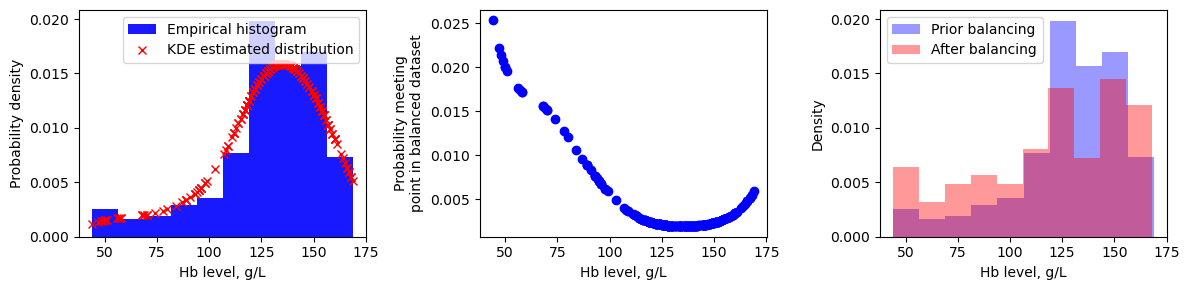

In [31]:
np.random.seed(42)

target_kde = stats.gaussian_kde(target,bw_method=0.5)(target)
weights = 1/target_kde
weights /= np.sum(weights)

patient_ids = metadata['PATIENT_ID']
balanced_patient_ids = np.random.choice(patient_ids,size=100,replace=False,p=weights)
balancing_mask = metadata['PATIENT_ID'].isin(balanced_patient_ids).values

plt.figure(figsize=(12,3))
plt.subplot(1,3,1)

plt.hist(target,density=True,label='Empirical histogram',color='b',alpha=0.9)
plt.plot(target,target_kde,'x',color='r',label='KDE estimated distribution')

plt.legend()
plt.ylabel("Probability density")
plt.xlabel("Hb level, g/L")

plt.subplot(1,3,2)
plt.plot(target,weights,'o',color='b')

plt.ylabel("Probability meeting\npoint in balanced dataset")
plt.xlabel("Hb level, g/L")

plt.subplot(1,3,3)
plt.hist(target,density=True,alpha=0.4,label='Prior balancing',color='b')
plt.hist(target[balancing_mask],density=True,alpha=0.4,label='After balancing',color='r')

plt.xlabel("Hb level, g/L")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

In [32]:
np.mean(target < 120)

0.276

In [33]:
np.mean(target[balancing_mask] < 120)

0.44

In [34]:
X = features[balancing_mask]
y = target[balancing_mask]

In [35]:
cv_scheme = sklearn.model_selection.KFold(n_splits=7)
scoring = sklearn.metrics.make_scorer(sklearn.metrics.mean_squared_error,greater_is_better=False,squared=False)

In [36]:
model = sklearn.pipeline.Pipeline(
    steps=[
        ('scaler',sklearn.preprocessing.RobustScaler()),
        ('regressor',sklearn.linear_model.ElasticNet(max_iter=10000))
    ]
)

In [37]:
grid_searcher = sklearn.model_selection.GridSearchCV(model,
                                                     param_grid={'regressor__l1_ratio':[0.01,0.1,0.5,0.9,0.99],
                                                                 'regressor__alpha':np.logspace(-4,4,num=100)},
                                                    verbose=1,
                                                    cv=cv_scheme,return_train_score=True,
                                                    scoring=scoring)

In [38]:
grid_searcher.fit(X,y)

Fitting 7 folds for each of 500 candidates, totalling 3500 fits


GridSearchCV(cv=KFold(n_splits=7, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('scaler', RobustScaler()),
                                       ('regressor',
                                        ElasticNet(max_iter=10000))]),
             param_grid={'regressor__alpha': array([1.00000000e-04, 1.20450354e-04, 1.45082878e-04, 1.74752840e-04,
       2.10490414e-04, 2.53536449e-04, 3.05385551e-04, 3.67837977e-04,
       4.43062146e-04, 5.33669923e-04, 6...
       1.29154967e+03, 1.55567614e+03, 1.87381742e+03, 2.25701972e+03,
       2.71858824e+03, 3.27454916e+03, 3.94420606e+03, 4.75081016e+03,
       5.72236766e+03, 6.89261210e+03, 8.30217568e+03, 1.00000000e+04]),
                         'regressor__l1_ratio': [0.01, 0.1, 0.5, 0.9, 0.99]},
             return_train_score=True,
             scoring=make_scorer(mean_squared_error, greater_is_better=False, response_method='predict', squared=False),
             verbose=1)

In [40]:
grid_searcher.best_score_

-23.855790190683877

In [39]:
grid_searcher.best_params_

{'regressor__alpha': 0.20565123083486536, 'regressor__l1_ratio': 0.9}

In [41]:
best_model = model.set_params(**grid_searcher.best_params_)

In [42]:
y_pred = sklearn.model_selection.cross_val_predict(best_model,X,y=y,cv=cv_scheme)

In [43]:
best_model.fit(X,y)

Pipeline(steps=[('scaler', RobustScaler()),
                ('regressor',
                 ElasticNet(alpha=0.20565123083486536, l1_ratio=0.9,
                            max_iter=10000))])

In [44]:
test_patients = ~balancing_mask

X_test = features[test_patients]
y_test = target[test_patients]

In [45]:
y_pred_test = best_model.predict(X_test)

In [46]:
val_rmse = sklearn.metrics.mean_squared_error(y,y_pred,squared=False)
test_rmse = sklearn.metrics.mean_squared_error(y_test,y_pred_test,squared=False)

Validation set bias: 0.4 g/L
Validation set (bias - 1.96*SD, bias + 1.96*SD): (-46.6,47.5) g/L)
------
Test set bias: -4.3 g/L
Test set (bias - 1.96*SD, bias + 1.96*SD): (-43.1,34.5) g/L)
------


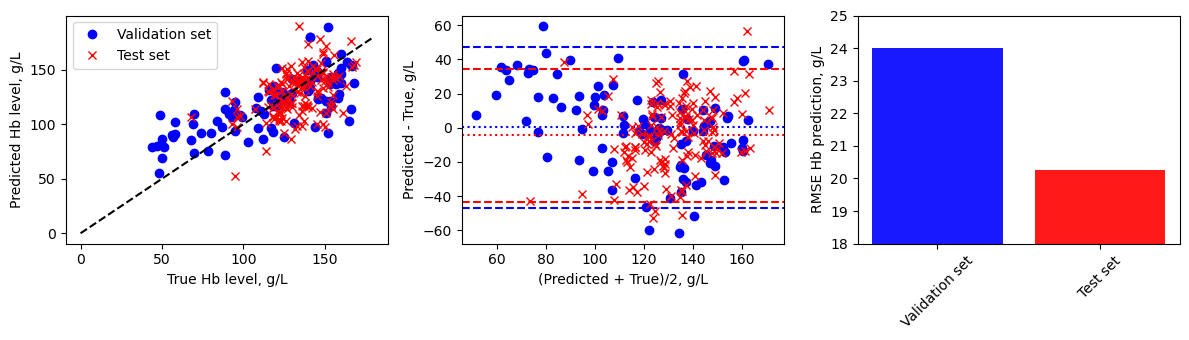

In [47]:
plt.figure(figsize=(12,3.5))
plt.subplot(1,3,1)

plt.plot(y,y_pred,'bo',label='Validation set')
plt.plot(y_test,y_pred_test,'rx',label='Test set')
plt.plot(np.linspace(0,180),np.linspace(0,180),color='k',linestyle='dashed')

plt.legend()
plt.ylabel("Predicted Hb level, g/L")
plt.xlabel("True Hb level, g/L")

plt.subplot(1,3,2)

sets = [[y, y_pred,'Validation set'],
        [y_test,y_pred_test, 'Test set']]

marker_style = {"Validation set":'o','Test set':'x'}
colors = {"Validation set": 'b','Test set':'r'}

for _true,_pred, _set_type in sets:
    
    _avg = (_true + _pred)/2.
    _diff = _pred - _true
    
    _SD = np.std(_diff)
    _bias = np.mean(_diff)
    
    color = colors[_set_type]
    plt.plot(_avg,_diff,color=color,linestyle='None', marker=marker_style[_set_type])
    
    plt.axhline(_bias,linestyle='dotted',color=color)
    
    plt.axhline(_bias + 1.96*_SD,linestyle='dashed',color=color)
    plt.axhline(_bias - 1.96*_SD,linestyle='dashed',color=color)
    
    print(f'{_set_type} bias: {_bias:.1f} g/L')
    print(f'{_set_type} (bias - 1.96*SD, bias + 1.96*SD): ({_bias - 1.96*_SD:.1f},{_bias + 1.96*_SD:.1f}) g/L)')
    
    print('------')
plt.ylabel("Predicted - True, g/L")
plt.xlabel("(Predicted + True)/2, g/L")


plt.subplot(1,3,3)

plt.bar([0,1],[val_rmse,test_rmse],color=['b','r'],alpha=0.9)
plt.xticks([0,1],['Validation set','Test set'],rotation=45)
plt.ylabel("RMSE Hb prediction, g/L")
plt.ylim(18,25)
plt.tight_layout()